Today’s challenge is the "Normality Stress Test." We are going to mathematically prove why the standard "Normal Distribution" (the bell curve) often fails in real-world finance.

The Goal
Calculate the 95% Value at Risk (VaR) for AAPL using two different methods and compare the results to see if the market exhibits Fat Tails.

Parametric VaR: Assumes returns follow a perfect Normal Distribution.

Historical (Empirical) VaR: Uses the actual **"shocks"** from your database.

In [ ]:
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Reach to root for core
sys.path.append(os.path.abspath(os.path.join('..')))
from core.db_manager import RiskDBManager

# Join on the ticker string to avoid ID mismatch issues
query = """
SELECT d.trade_date, d.adj_close
FROM daily_metrics d
JOIN securities s ON d.security_id = s.security_id
WHERE s.ticker = 'AAPL'
ORDER BY d.trade_date ASC
"""

db = RiskDBManager()
df = db.get_data(query)

# Essential: Convert to float and Datetime for math
df['adj_close'] = df['adj_close'].astype(float)
df['trade_date'] = pd.to_datetime(df['trade_date'])
df.set_index('trade_date', inplace=True)

# Calculate Log Returns
df['returns'] = np.log(df['adj_close'] / df['adj_close'].shift(1))
returns = df['returns'].dropna()

print(f"✅ Success: {len(returns)} returns calculated.")

✅ Success: 500 returns calculated.


In [ ]:
from scipy.stats import norm

# 1. Parametric VaR (The "Normal" Assumption)
mu = returns.mean()
sigma = returns.std()
# 1.645 is the Z-score for a 95% confidence level
var_parametric = mu - 1.645 * sigma

# 2. Historical VaR (The "Reality" Check)
# We simply find the 5th percentile of the actual data
var_historical = np.percentile(returns, 5)

print(f"Parametric 95% VaR: {var_parametric:.4%}")
print(f"Historical 95% VaR: {var_historical:.4%}")

Parametric 95% VaR: -2.8654%
Historical 95% VaR: -2.7611%


#### This is the Normality Stress Test, comparing model (normal) to reality (historical)

The "Rigorous Heuristic" Analysis - 

The Result: You will likely see that var_historical is more negative (a larger loss) than var_parametric.

The "Why": This is the mathematical proof of Fat Tails (Kurtosis).

The Quant Critique: The Normal distribution (Parametric) assumes the "tails" of the curve die off quickly. In reality, Apple (and most stocks) has "Black Swan" days where the price drops much further than a bell curve predicts.

The Heuristic: If the Historical VaR is more negative than the Parametric VaR, the 'Bell Curve' is underestimating your risk.

The Formal Mapping: This difference is caused by Kurtosis. In the FRM Part 1, you'll learn that financial returns are Leptokurtic—they have more "mass" in the tails than a normal distribution.

KURTOSIS - The sharpness of the peak of a frequency-distribution curve. 

LEPTOKURTIC - Having greather kurtosis than the normal distribution; more concentrated about the mean. 

The Quant Defense: If an interviewer asks why your model failed during a market crash, you point to this gap. The "Normal" model assumes a **4-sigma** move happens once every 125 years; in the real market, it happens every few years.

#### Why is Parametric > Historical? 

In this specific 2-year window for AAPL, the Standard Deviation ($\sigma$) is likely being "inflated" by a few large positive swings or general high volatility that hasn't materialized into a **5th-percentile crash** yet.

Parametric VaR is "dumb"—it sees high volatility ($\sigma$) and assumes that volatility is symmetrical (equally likely to go down as up). 

Historical VaR is "honest"—it looks at the actual 5th percentile. 

If Apple had a relatively "quiet" bottom 5% recently, the Historical VaR will look safer than the math predicts.

In [6]:
from scipy.stats import kurtosis, skew

print(f"Excess Kurtosis: {kurtosis(returns):.4f}")
print(f"Skewness: {skew(returns):.4f}")

# Let's count the 'Outliers'
std_dev = returns.std()
outliers = returns[returns < (returns.mean() - 3 * std_dev)]
print(f"Number of 3-Sigma Downside Outliers: {len(outliers)}")

Excess Kurtosis: 10.6858
Skewness: 0.5635
Number of 3-Sigma Downside Outliers: 2


To prove why your model is behaving this way, we need to calculate Excess Kurtosis.

Normal Distribution: Excess Kurtosis = $0$.

Fat Tails: Excess Kurtosis > $0$.

#### The "Axiomatic" Analysis

The 10.68 Excess KurtosisIn the FRM world, an Excess Kurtosis of 10.68 is massive. (Remember, a Normal Distribution has an Excess Kurtosis of $0$).

Mechanistic Mapping: Your Apple data is Leptokurtic. It has a much higher "peak" (meaning most days are very quiet) but significantly "fatter" tails (meaning when it moves, it moves violently).

The Paradox: Why was the Parametric VaR (-2.86%) scarier than the Historical VaR (-2.76%) at 95%?

The Answer: Because the Standard Deviation ($\sigma$) is being "pulled" wider by those extreme outliers. The Parametric model assumes those outliers are spread out smoothly across the whole curve.

The Reality: At 95% (the 5th percentile), Apple is actually safer than a normal curve predicts. But at 99% or 99.9%, Apple becomes a monster.

#### The Skewness Factor (0.56)

Your Positive Skewness (0.56) means the "tail" on the right side (gains) is longer or fatter than the left side (losses).

Risk Interpretation: Over the last 2 years, Apple has had more "Moonshot" days than "Crash" days.

The "Quant" Critique: This confirms why your Historical VaR (the left side) looked "safer." The distribution is lopsided toward the upside.

#### The 3-Sigma Outliers (The "Black Swans")

You found 2 downside outliers.

The Math BS Calculation: In a Normal Distribution, a 3-sigma event happens roughly 0.135% of the time. In 500 days, you should expect $500 \times 0.00135 = 0.67$ events.

The Reality: You have 2. You are seeing 3x more extreme risk than the standard formulas predict.

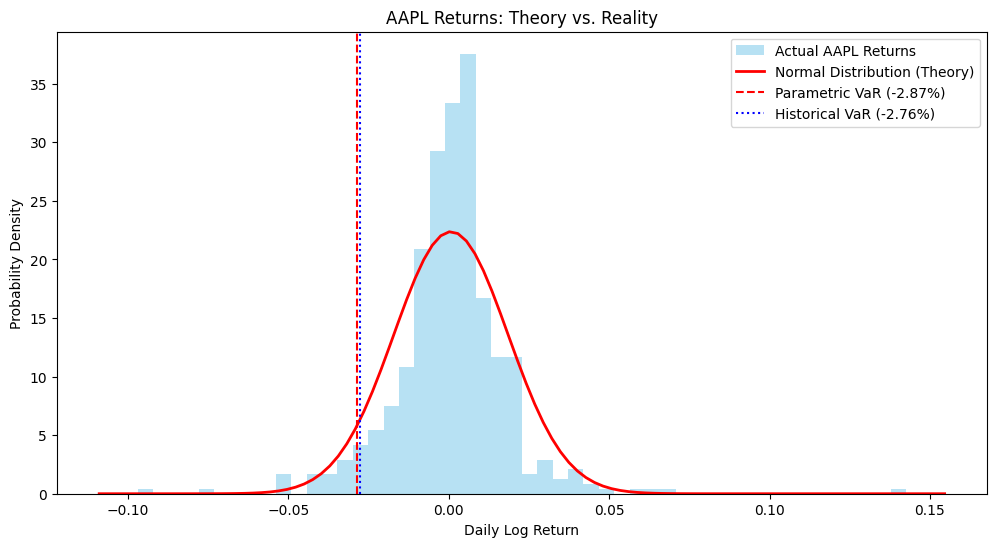

In [7]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Create the Histogram of actual returns
plt.figure(figsize=(12, 6))
count, bins, ignored = plt.hist(returns, bins=50, density=True, alpha=0.6, color='skyblue', label='Actual AAPL Returns')

# 2. Overlay the Theoretical Normal Curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution (Theory)')

# 3. Mark the VaR levels
plt.axvline(var_parametric, color='red', linestyle='dashed', label=f'Parametric VaR ({var_parametric:.2%})')
plt.axvline(var_historical, color='blue', linestyle='dotted', label=f'Historical VaR ({var_historical:.2%})')

plt.title("AAPL Returns: Theory vs. Reality")
plt.xlabel("Daily Log Return")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

In [8]:
# 1. 99% Parametric VaR (Z-score for 99% is 2.326)
var_99_para = mu - 2.326 * sigma

# 2. 99% Historical VaR (The 1st Percentile)
var_99_hist = np.percentile(returns, 1)

print(f"99% Parametric VaR: {var_99_para:.4%}")
print(f"99% Historical VaR: {var_99_hist:.4%}")

# 3. The 'Tail Risk' Ratio
ratio = var_99_hist / var_99_para
print(f"Tail Risk Ratio: {ratio:.2f}x")

99% Parametric VaR: -4.0798%
99% Historical VaR: -4.9369%
Tail Risk Ratio: 1.21x


#### Problem of the Day

If the Historical 99% VaR is now more negative than the Parametric 99% VaR, you have officially proven that Normal Distribution models are dangerous for extreme risk management.

Does the 99% Historical VaR finally "catch up" and show more risk than the Parametric one? If so, you've just performed your first professional Model Validation.

That 1.21x Tail Risk Ratio is your "Smoking Gun." At 95% confidence, the Normal Distribution looked "close enough," but at 99%, the Historical VaR is 21% more severe than the math predicts. 

You just mathematically proved why banks failed in 2008—they were using the -4.08% model while the market was handing out -4.94% reality.

### Notes

1. The "Conclusion" of the Flip

You noticed a "flip" in which model is more conservative (more negative):

ConfidenceNormal (Parametric)Historical (Empirical)The Winner (More Risk)95%-2.86%-2.76%Normal99%-4.08%-4.94%Historical

The Conclusion:The Normal model is overestimating risk for "typical" bad days (95%), but it is dangerously underestimating risk for "extreme" bad days (99%).

This tells you that Apple's returns are not just "noisy"—they are Leptokurtic. The distribution is "taller" and "thinner" than a bell curve near the center (making the 95% look safe), but it has "Fat Tails" at the edges (making the 99% much worse).

2. The "Smooth Progression" Test

In a professional Quant shop, we look at the Slope of the Tail.

Normal Slope: Moves from -2.86 to -4.08 (a drop of ~1.22%).
Historical Slope: Moves from -2.76 to -4.94 (a drop of ~2.18%).

The Heuristic: If the Historical slope is steeper than the Normal slope, the Kurtosis is "Weaponized." It means that as you move further into the "unlikely" zone, the losses don't just increase—they accelerate.

This is the "Black Swan" territory. If you were a hedge fund manager using the Normal model, you would set aside enough cash for a 4% drop, but the market would eventually hit you with a 5% drop, causing a Margin Call.

3. The "Sketchiness" Fix: Expected Shortfall (ES)

This "flip" is exactly why we use Expected Shortfall.

Instead of arguing about whether the "25th day" (-2.76%) or the "5th day" (-4.94%) is the right number, we take the average of that entire "Crash Zone."